# Notebook 3 - VAE Training

This notebook implements and trains the VAE architectures described in the paper:

1. **Single-Currency VAE** : trained on one currency at a time
2. **Multi-Currency VAE** : trained on all currencies with shared latent space
3. **Multi-Currency CVAE** : conditional VAE with one-hot currency encoding

### Architecture (Table 1-3 in the paper):
- **Input**: N=7 swap rates (2Y, 3Y, 5Y, 10Y, 15Y, 20Y, 30Y)
- **Latent space**: K=2 dimensions
- **Pre-processing**: linear map from [-5%, 25%] to [0, 1]
- **Loss**: L2 reconstruction + β·KLD (β = 1e-7)

The multi-currency VAE is the **recommended** architecture per the paper.

## 0 - Imports

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from typing import Optional, Dict, Tuple
from pathlib import Path
from matplotlib.patches import Ellipse

Path("figs").mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 1 - Configuration & Data

In [83]:
SEED = 42 #reproductibility
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [84]:
# Load data
with open("clean_swap_data.pkl", "rb") as f:
    data = pickle.load(f)

swap_data = data["swap_data"]          # per-ccy, full date ranges
swap_aligned = data["swap_aligned"]    # aligned across currencies
TARGET_TENORS = data["target_tenors"]  # [2,3,5,10,15,20,30]

In [85]:
# Use all available currencies in swap_aligned
CURRENCIES = list(swap_aligned.keys())
N_CCY = len(CURRENCIES)
CCY_TO_IDX = {c: i for i, c in enumerate(CURRENCIES)}

In [86]:
print("Dataset used: swap_aligned")
for ccy, df in swap_aligned.items():
    print(f"  {ccy}: {df.shape[0]} obs × {df.shape[1]} tenors")

Dataset used: swap_aligned
  GBP: 712 obs × 7 tenors
  EUR: 712 obs × 7 tenors
  USD: 712 obs × 7 tenors
  JPY: 712 obs × 7 tenors


## 2 - Data pre-processing

Following the paper exactly:
- Map swap rates from [S_min, S_max] = [-5%, 25%] to [0, 1] using linear transform
- This matches the Sigmoid output activation of the decoder

In [87]:
S_MIN = -0.05   # lower bound in %
S_MAX = 0.25    # upper bound in %
BP_PER_UNIT = 10000.0 

In [88]:
def normalize_rates(rates: np.ndarray) -> np.ndarray:
    """
    Map swap rates (decimal) from [S_MIN, S_MAX] to [0, 1].
    Clipped to [0,1] for numerical safety.
    """
    x = (rates - S_MIN) / (S_MAX - S_MIN)
    return np.clip(x, 0.0, 1.0)

def denormalize_rates(normed: np.ndarray) -> np.ndarray:
    """Map from [0, 1] back to swap rates (decimal)."""
    return normed * (S_MAX - S_MIN) + S_MIN

In [89]:
# Single-currency: dict of tensors
single_ccy_data: Dict[str, Dict] = {}
for ccy in CURRENCIES:
    df = swap_data[ccy]                 # full history per currency
    rates = df.values.astype(np.float32)  # decimal
    rates_norm = normalize_rates(rates).astype(np.float32)
    single_ccy_data[ccy] = {
        "raw": rates,  # decimal
        "norm": rates_norm,
        "tensor": torch.from_numpy(rates_norm),
        "dates": df.index,
    }

In [90]:
# Multi-currency aligned dataset (shared latent space)
multi_rates = []
multi_labels = []   # one-hot for CVAE
multi_ccy_ids = []
multi_dates = []

In [91]:
for ccy in CURRENCIES:
    df = swap_aligned[ccy]
    rates = df.values.astype(np.float32)     
    rates_norm = normalize_rates(rates).astype(np.float32)
    n = len(rates_norm)

    one_hot = np.zeros((n, N_CCY), dtype=np.float32)
    one_hot[:, CCY_TO_IDX[ccy]] = 1.0

    multi_rates.append(rates_norm)
    multi_labels.append(one_hot)
    multi_ccy_ids.extend([ccy] * n)
    multi_dates.extend(df.index.tolist())

multi_rates = np.vstack(multi_rates)      # (n_total, 7)
multi_labels = np.vstack(multi_labels)    # (n_total, C)

# Tensors
X_multi = torch.from_numpy(multi_rates)
Y_multi = torch.from_numpy(multi_labels)

print(f"\nMulti-currency dataset: {X_multi.shape[0]} samples × {X_multi.shape[1]} features")
print(f"Currency distribution: {pd.Series(multi_ccy_ids).value_counts().to_dict()}")


Multi-currency dataset: 2848 samples × 7 features
Currency distribution: {'GBP': 712, 'EUR': 712, 'USD': 712, 'JPY': 712}


## 3 - VAE Architecture

We implement all three architectures from Tables 1-3 of the paper.

In [92]:
class VAE(nn.Module):
    """
    VAE for swap curves.
    - single-currency: Table 1 style
    - multi-currency: Table 2 style (deeper decoder)
    """

    def __init__(self, input_dim: int = 7, latent_dim: int = 2, hidden_dim: int = 4, multi_currency: bool = False):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.multi_currency = multi_currency

        if not multi_currency:
            # Single-currency (Table 1 style)
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.Tanh(),
                nn.Linear(hidden_dim, 2 * latent_dim),  # [mu | logvar]
            )
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim),
                nn.Tanh(),
                nn.Linear(hidden_dim, input_dim),
                nn.Sigmoid(),
            )
        else:
            # Multi-currency (Table 2 style)
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, input_dim),
                nn.Tanh(),
                nn.Linear(input_dim, 2 * latent_dim),
            )
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim),
                nn.Tanh(),
                nn.Linear(hidden_dim, input_dim),
                nn.Tanh(),
                nn.Linear(input_dim, input_dim),
                nn.Sigmoid(),
            )

    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x)
        mu = h[:, :self.latent_dim]
        logvar = h[:, self.latent_dim:]
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + std * eps
        return mu

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

    def get_latent(self, x: torch.Tensor) -> np.ndarray:
        self.eval()
        with torch.no_grad():
            mu, _ = self.encode(x.to(next(self.parameters()).device))
        return mu.cpu().numpy()

In [93]:
class CVAE(nn.Module):
    """
    Conditional VAE (Table 3 style): one-hot currency concatenated to encoder/decoder inputs.
    """

    def __init__(self, input_dim: int = 7, latent_dim: int = 2, n_currencies: int = 4):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.n_currencies = n_currencies

        enc_in = input_dim + n_currencies
        dec_in = latent_dim + n_currencies

        self.encoder = nn.Sequential(
            nn.Linear(enc_in, enc_in - 1),
            nn.Tanh(),
            nn.Linear(enc_in - 1, 2 * latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(dec_in, input_dim),
            nn.Tanh(),
            nn.Linear(input_dim, input_dim),
            nn.Tanh(),
            nn.Linear(input_dim, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(torch.cat([x, y], dim=-1))
        mu = h[:, :self.latent_dim]
        logvar = h[:, self.latent_dim:]
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + std * eps
        return mu

    def decode(self, z: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return self.decoder(torch.cat([z, y], dim=-1))

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z, y)
        return x_recon, mu, logvar

    def get_latent(self, x: torch.Tensor, y: torch.Tensor) -> np.ndarray:
        self.eval()
        with torch.no_grad():
            mu, _ = self.encode(x.to(next(self.parameters()).device), y.to(next(self.parameters()).device))
        return mu.cpu().numpy()

In [94]:
print("\n Model classes defined")
print(f"   VAE single-ccy params: {sum(p.numel() for p in VAE(7, 2).parameters()):,}")
print(f"   VAE multi-ccy params:  {sum(p.numel() for p in VAE(7, 2, multi_currency=True).parameters()):,}")
print(f"   CVAE params:           {sum(p.numel() for p in CVAE(7, 2, N_CCY).parameters()):,}")


 Model classes defined
   VAE single-ccy params: 99
   VAE multi-ccy params:  191
   CVAE params:           325


## 4 - Loss function

From Eq. (5) of the paper:
$$\mathcal{L}_{VAE} = \frac{1}{N} D_{L2}(S, S') + \beta \cdot D_{KLD}(\mu, \sigma)$$
where $\beta = 10^{-7}$.

In [95]:
def vae_loss(
    x_recon: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = 1e-7,
    N: int = 7,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    VAE loss as defined in Eq. (5) of Sokol (2022).
    """
    # L2 reconstruction loss (per sample, averaged over N rates)
    recon = torch.mean((x_recon - x)**2, dim=-1)  # (batch,)
    recon_loss = torch.mean(recon) / N  # normalize by N as in paper
    
    # KLD loss: -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kld = -0.5 * torch.sum(1 + logvar - mu**2 - torch.exp(logvar), dim=-1)
    kld_loss = torch.mean(kld)
    
    total = recon_loss + beta * kld_loss
    return total, recon_loss, kld_loss

## 5 - Training loop

In [96]:
def train_vae(
    model: nn.Module,
    X_train: torch.Tensor,
    Y_train: Optional[torch.Tensor] = None,
    n_epochs: int = 2000,
    batch_size: int = 256,
    lr: float = 1e-3,
    beta: float = 1e-7,
    print_every: int = 200,
    scheduler_patience: int = 150,
) -> Dict[str, list]:
    model.to(device)
    is_cvae = isinstance(model, CVAE)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=scheduler_patience, factor=0.5, verbose=False
    )

    if is_cvae:
        assert Y_train is not None, "CVAE requires Y_train one-hot labels"
        dataset = TensorDataset(X_train, Y_train)
    else:
        dataset = TensorDataset(X_train)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    history = {"total": [], "recon": [], "kld": [], "lr": []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        tot = rec = kldv = 0.0
        n_batches = 0

        for batch in loader:
            if is_cvae:
                x_batch, y_batch = batch[0].to(device), batch[1].to(device)
                x_recon, mu, logvar = model(x_batch, y_batch)
                loss, recon, kld = vae_loss(x_recon, x_batch, mu, logvar, beta=beta)
            else:
                x_batch = batch[0].to(device)
                x_recon, mu, logvar = model(x_batch)
                loss, recon, kld = vae_loss(x_recon, x_batch, mu, logvar, beta=beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            tot += float(loss.item())
            rec += float(recon.item())
            kldv += float(kld.item())
            n_batches += 1

        tot /= n_batches
        rec /= n_batches
        kldv /= n_batches

        history["total"].append(tot)
        history["recon"].append(rec)
        history["kld"].append(kldv)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        scheduler.step(tot)

        if epoch == 1 or epoch % print_every == 0:
            print(
                f"  Epoch {epoch:5d}/{n_epochs} | "
                f"Loss: {tot:.6e} | Recon: {rec:.6e} | KLD: {kldv:.3e} | LR: {optimizer.param_groups[0]['lr']:.1e}"
            )

    model.eval()
    return history

## 6 - Train all three architectures

In [97]:
print("\n" + "=" * 72)
print("Training SINGLE-CURRENCY VAEs")
print("=" * 72)

single_vae_models: Dict[str, VAE] = {}
single_vae_histories: Dict[str, Dict] = {}

for ccy in CURRENCIES:
    print(f"\n{'─'*50}\n  {ccy}\n{'─'*50}")
    model = VAE(input_dim=7, latent_dim=2, hidden_dim=4, multi_currency=False)
    X = single_ccy_data[ccy]["tensor"]
    hist = train_vae(model, X, n_epochs=2000, batch_size=128, lr=1e-3, beta=1e-7, print_every=200)
    single_vae_models[ccy] = model
    single_vae_histories[ccy] = hist


Training SINGLE-CURRENCY VAEs

──────────────────────────────────────────────────
  GBP
──────────────────────────────────────────────────


  Epoch     1/2000 | Loss: 8.264487e-03 | Recon: 8.264471e-03 | KLD: 1.569e-01 | LR: 1.0e-03
  Epoch   200/2000 | Loss: 3.210701e-05 | Recon: 3.164636e-05 | KLD: 4.607e+00 | LR: 1.0e-03
  Epoch   400/2000 | Loss: 2.986092e-05 | Recon: 2.930012e-05 | KLD: 5.608e+00 | LR: 1.0e-03
  Epoch   600/2000 | Loss: 2.904904e-05 | Recon: 2.843096e-05 | KLD: 6.181e+00 | LR: 1.0e-03
  Epoch   800/2000 | Loss: 2.897464e-05 | Recon: 2.832414e-05 | KLD: 6.505e+00 | LR: 1.0e-03
  Epoch  1000/2000 | Loss: 2.899105e-05 | Recon: 2.832870e-05 | KLD: 6.624e+00 | LR: 5.0e-04
  Epoch  1200/2000 | Loss: 2.886726e-05 | Recon: 2.821463e-05 | KLD: 6.526e+00 | LR: 5.0e-04
  Epoch  1400/2000 | Loss: 2.891950e-05 | Recon: 2.828550e-05 | KLD: 6.340e+00 | LR: 2.5e-04
  Epoch  1600/2000 | Loss: 2.867643e-05 | Recon: 2.807113e-05 | KLD: 6.053e+00 | LR: 2.5e-04
  Epoch  1800/2000 | Loss: 2.863570e-05 | Recon: 2.806139e-05 | KLD: 5.743e+00 | LR: 1.3e-04
  Epoch  2000/2000 | Loss: 2.878206e-05 | Recon: 2.823523e-05 | KLD: 5

In [98]:
print("\n" + "=" * 72)
print("Training MULTI-CURRENCY VAE (shared latent space)")
print("=" * 72)
multi_vae = VAE(input_dim=7, latent_dim=2, hidden_dim=4, multi_currency=True)
multi_vae_history = train_vae(multi_vae, X_multi, n_epochs=3000, batch_size=256, lr=1e-3, beta=1e-7, print_every=300)



Training MULTI-CURRENCY VAE (shared latent space)
  Epoch     1/3000 | Loss: 6.096495e-03 | Recon: 6.096490e-03 | KLD: 4.979e-02 | LR: 1.0e-03
  Epoch   300/3000 | Loss: 9.875661e-06 | Recon: 9.067404e-06 | KLD: 8.083e+00 | LR: 1.0e-03
  Epoch   600/3000 | Loss: 9.266849e-06 | Recon: 8.588398e-06 | KLD: 6.785e+00 | LR: 1.0e-03
  Epoch   900/3000 | Loss: 9.022022e-06 | Recon: 8.423549e-06 | KLD: 5.985e+00 | LR: 1.0e-03
  Epoch  1200/3000 | Loss: 8.780770e-06 | Recon: 8.284809e-06 | KLD: 4.960e+00 | LR: 1.0e-03
  Epoch  1500/3000 | Loss: 8.838542e-06 | Recon: 8.354343e-06 | KLD: 4.842e+00 | LR: 2.5e-04
  Epoch  1800/3000 | Loss: 8.498090e-06 | Recon: 8.019925e-06 | KLD: 4.782e+00 | LR: 6.3e-05
  Epoch  2100/3000 | Loss: 8.704560e-06 | Recon: 8.228589e-06 | KLD: 4.760e+00 | LR: 3.1e-05
  Epoch  2400/3000 | Loss: 8.972596e-06 | Recon: 8.495663e-06 | KLD: 4.769e+00 | LR: 7.8e-06
  Epoch  2700/3000 | Loss: 8.702843e-06 | Recon: 8.227241e-06 | KLD: 4.756e+00 | LR: 2.0e-06
  Epoch  3000/3000 

In [99]:
print("\n" + "=" * 72)
print("Training MULTI-CURRENCY CVAE (conditional)")
print("=" * 72)
cvae = CVAE(input_dim=7, latent_dim=2, n_currencies=N_CCY)
cvae_history = train_vae(cvae, X_multi, Y_train=Y_multi, n_epochs=3000, batch_size=256, lr=1e-3, beta=1e-7, print_every=300)



Training MULTI-CURRENCY CVAE (conditional)
  Epoch     1/3000 | Loss: 9.899317e-03 | Recon: 9.899306e-03 | KLD: 1.137e-01 | LR: 1.0e-03
  Epoch   300/3000 | Loss: 2.260812e-05 | Recon: 2.186074e-05 | KLD: 7.474e+00 | LR: 1.0e-03
  Epoch   600/3000 | Loss: 8.131448e-06 | Recon: 7.268406e-06 | KLD: 8.630e+00 | LR: 1.0e-03
  Epoch   900/3000 | Loss: 1.327543e-06 | Recon: 4.004660e-07 | KLD: 9.271e+00 | LR: 1.0e-03
  Epoch  1200/3000 | Loss: 1.230946e-06 | Recon: 3.383008e-07 | KLD: 8.926e+00 | LR: 1.0e-03
  Epoch  1500/3000 | Loss: 1.160378e-06 | Recon: 3.076963e-07 | KLD: 8.527e+00 | LR: 1.0e-03
  Epoch  1800/3000 | Loss: 1.124355e-06 | Recon: 3.079845e-07 | KLD: 8.164e+00 | LR: 1.0e-03
  Epoch  2100/3000 | Loss: 1.076166e-06 | Recon: 2.948935e-07 | KLD: 7.813e+00 | LR: 1.0e-03
  Epoch  2400/3000 | Loss: 1.039919e-06 | Recon: 2.893380e-07 | KLD: 7.506e+00 | LR: 1.0e-03
  Epoch  2700/3000 | Loss: 1.001635e-06 | Recon: 2.776864e-07 | KLD: 7.239e+00 | LR: 1.0e-03
  Epoch  3000/3000 | Loss:

## 7 - Plot training convergence plots

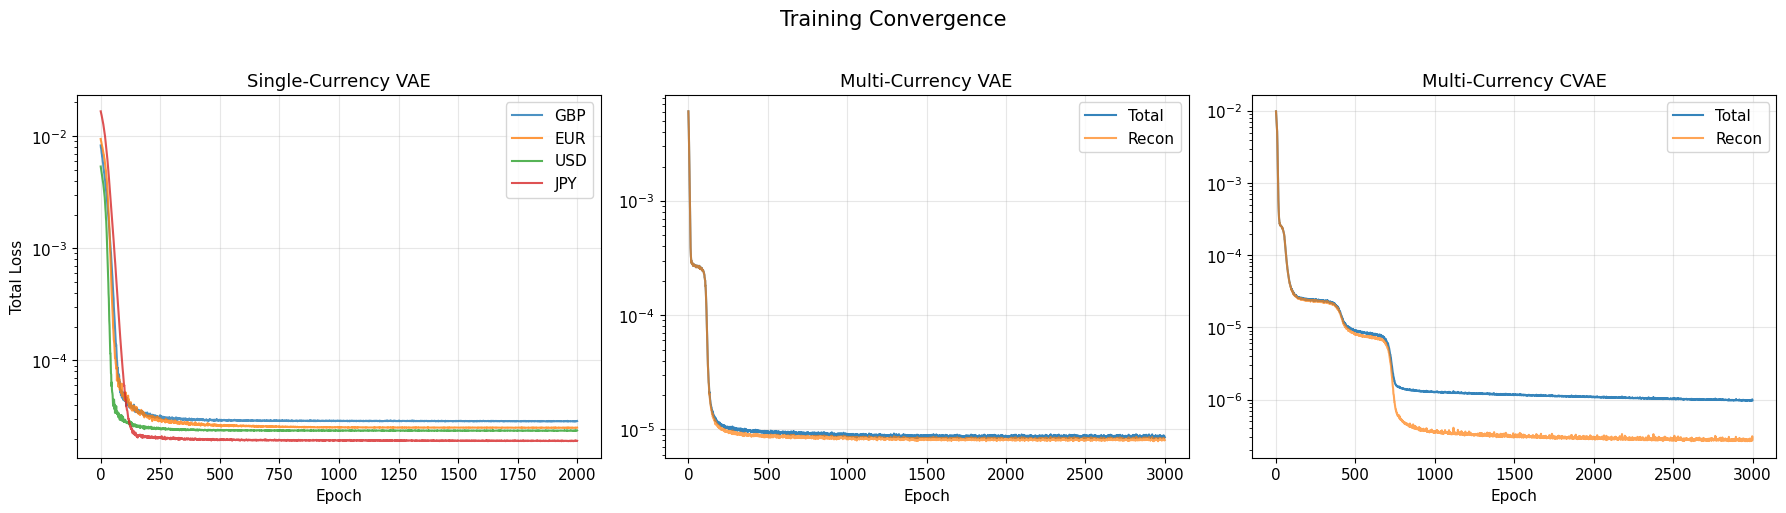

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Single-currency
ax = axes[0]
for ccy in CURRENCIES:
    ax.plot(single_vae_histories[ccy]["total"], label=ccy, alpha=0.8)
ax.set_title("Single-Currency VAE", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("Total Loss")
ax.set_yscale("log")
ax.legend()

# Multi-currency VAE
ax = axes[1]
ax.plot(multi_vae_history["total"], label="Total", alpha=0.9)
ax.plot(multi_vae_history["recon"], label="Recon", alpha=0.7)
ax.set_title("Multi-Currency VAE", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_yscale("log")
ax.legend()

# CVAE
ax = axes[2]
ax.plot(cvae_history["total"], label="Total", alpha=0.9)
ax.plot(cvae_history["recon"], label="Recon", alpha=0.7)
ax.set_title("Multi-Currency CVAE", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_yscale("log")
ax.legend()

plt.suptitle("Training Convergence", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("figs/fig_08_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 - Compute reconstruction RMSE for all models

In [101]:
def compute_rmse_bp(model: nn.Module, X_norm: torch.Tensor, Y_labels: Optional[torch.Tensor] = None):
    """
    RMSE per observation in basis points.
    """
    model.eval()
    with torch.no_grad():
        X_dev = X_norm.to(device)
        if isinstance(model, CVAE):
            assert Y_labels is not None
            Y_dev = Y_labels.to(device)
            X_recon, _, _ = model(X_dev, Y_dev)
        else:
            X_recon, _, _ = model(X_dev)

    X_recon_np = X_recon.cpu().numpy()
    X_true_np = X_norm.cpu().numpy()

    x_recon = denormalize_rates(X_recon_np)  # decimal
    x_true = denormalize_rates(X_true_np)    # decimal

    rmse_bp = np.sqrt(np.mean((x_recon - x_true) ** 2, axis=1)) * BP_PER_UNIT
    return rmse_bp, x_recon

In [102]:
rmse_results: Dict[str, np.ndarray] = {}

# Single-currency VAE
for ccy in CURRENCIES:
    X = single_ccy_data[ccy]["tensor"]
    rmse_bp, _ = compute_rmse_bp(single_vae_models[ccy], X)
    rmse_results[f"SingleVAE_{ccy}"] = rmse_bp

# Multi-currency VAE (per currency slices)
offset = 0
for ccy in CURRENCIES:
    n = len(swap_aligned[ccy])
    X_slice = X_multi[offset:offset+n]
    rmse_bp, _ = compute_rmse_bp(multi_vae, X_slice)
    rmse_results[f"MultiVAE_{ccy}"] = rmse_bp
    offset += n

# CVAE (per currency slices)
offset = 0
for ccy in CURRENCIES:
    n = len(swap_aligned[ccy])
    X_slice = X_multi[offset:offset+n]
    Y_slice = Y_multi[offset:offset+n]
    rmse_bp, _ = compute_rmse_bp(cvae, X_slice, Y_slice)
    rmse_results[f"CVAE_{ccy}"] = rmse_bp
    offset += n

In [103]:
print(f"\n{'Model':<20} {'Currency':<8} {'Mean(bp)':>10} {'Median':>10} {'95th':>10}")
print("─" * 64)
for key, rmse in rmse_results.items():
    model_name, ccy = key.rsplit("_", 1)
    print(f"{model_name:<20} {ccy:<8} {np.mean(rmse):>10.2f} {np.median(rmse):>10.2f} {np.percentile(rmse, 95):>10.2f}")



Model                Currency   Mean(bp)     Median       95th
────────────────────────────────────────────────────────────────
SingleVAE            GBP           36.86      36.19      75.98
SingleVAE            EUR           36.60      36.61      64.55
SingleVAE            USD           34.98      35.79      59.35
SingleVAE            JPY           28.16      24.54      58.13
MultiVAE             GBP           25.07      22.09      49.98
MultiVAE             EUR           19.27      19.24      30.61
MultiVAE             USD           20.87      18.63      40.35
MultiVAE             JPY           10.58       6.81      25.08
CVAE                 GBP            2.61       2.37       5.05
CVAE                 EUR            3.00       2.71       5.72
CVAE                 USD            3.11       2.50       7.07
CVAE                 JPY            2.78       2.59       5.28


## 9 - World map of latent space (Fig. 13 in paper)

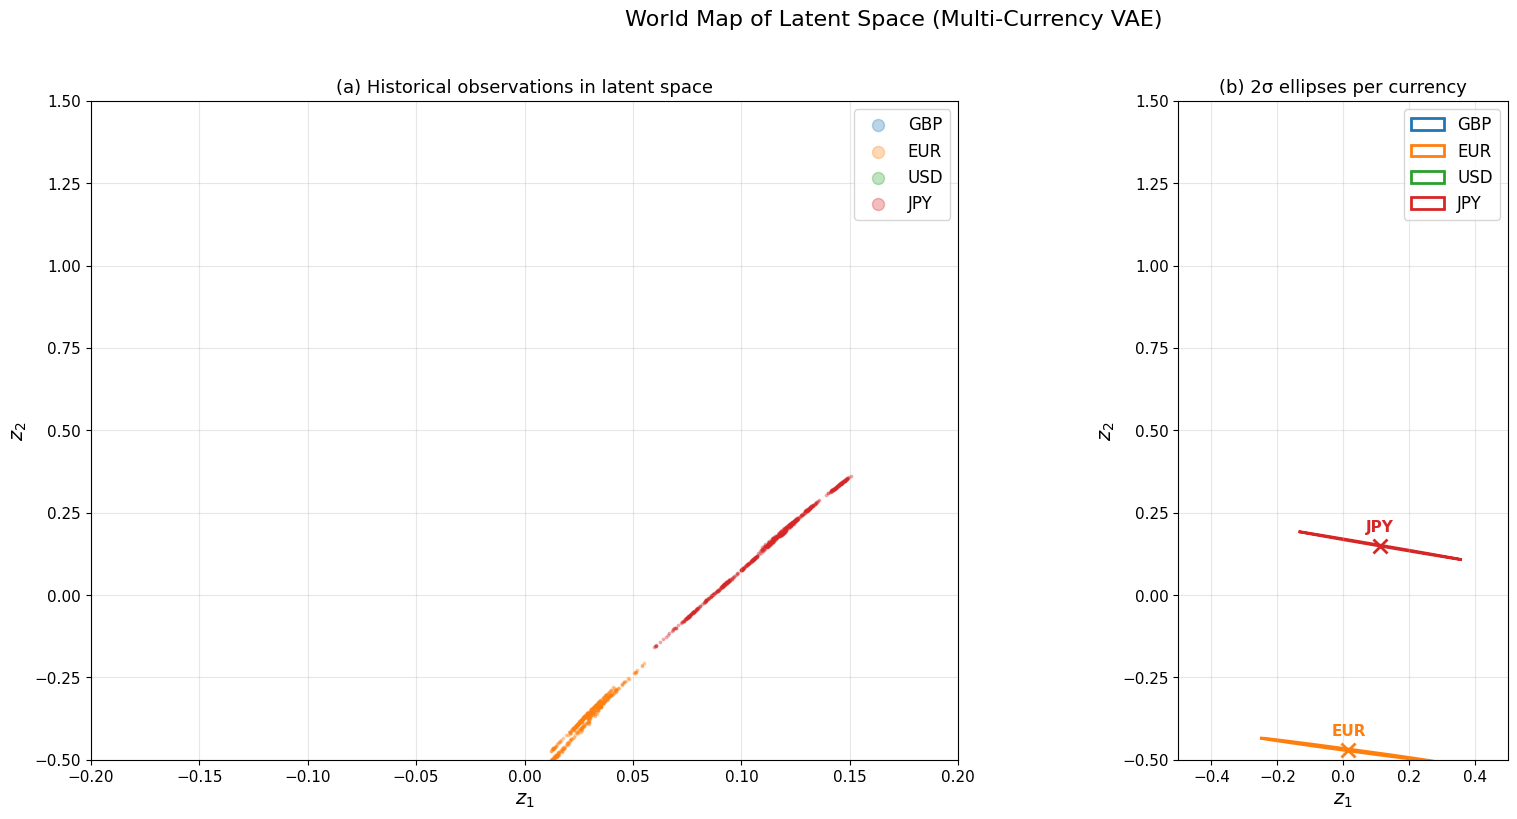

In [104]:
default_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = {ccy: default_cycle[i % len(default_cycle)] for i, ccy in enumerate(CURRENCIES)}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# (a) scatter
ax = axes[0]
offset = 0
for ccy in CURRENCIES:
    n = len(swap_aligned[ccy])
    X_slice = X_multi[offset:offset+n]
    z = multi_vae.get_latent(X_slice)
    ax.scatter(z[:, 0], z[:, 1], s=3, alpha=0.3, label=ccy, color=colors[ccy])
    offset += n
ax.set_xlabel("$z_1$", fontsize=14)
ax.set_ylabel("$z_2$", fontsize=14)
ax.set_title("(a) Historical observations in latent space", fontsize=13)
ax.legend(markerscale=5, fontsize=12)
ax.set_xlim(-0.2, 0.2)
ax.set_ylim(-0.5, 1.5)

# (b) 2σ ellipses
ax = axes[1]
offset = 0
for ccy in CURRENCIES:
    n = len(swap_aligned[ccy])
    X_slice = X_multi[offset:offset+n]
    z = multi_vae.get_latent(X_slice)

    mean = z.mean(axis=0)
    cov = np.cov(z.T)
    evals, evecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(evecs[1, 1], evecs[0, 1]))
    width, height = 2 * 2 * np.sqrt(evals)  # 2σ

    ell = Ellipse(xy=mean, width=width, height=height, angle=angle, fill=False, lw=2, color=colors[ccy], label=ccy)
    ax.add_patch(ell)
    ax.plot(mean[0], mean[1], "x", ms=10, mew=2, color=colors[ccy])
    ax.annotate(ccy, xy=mean, fontsize=11, fontweight="bold", color=colors[ccy],
                ha="center", va="bottom", xytext=(0, 8), textcoords="offset points")

    offset += n

ax.set_xlabel("$z_1$", fontsize=14)
ax.set_ylabel("$z_2$", fontsize=14)
ax.set_title("(b) 2σ ellipses per currency", fontsize=13)
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.5, 1.5)
ax.set_aspect("equal")
ax.legend(fontsize=12)

fig.suptitle("World Map of Latent Space (Multi-Currency VAE)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("figs/fig_09_world_map.png", dpi=150, bbox_inches="tight")
plt.show()


## 10 - Generated curves from latent space perimeter (Fig. 15)

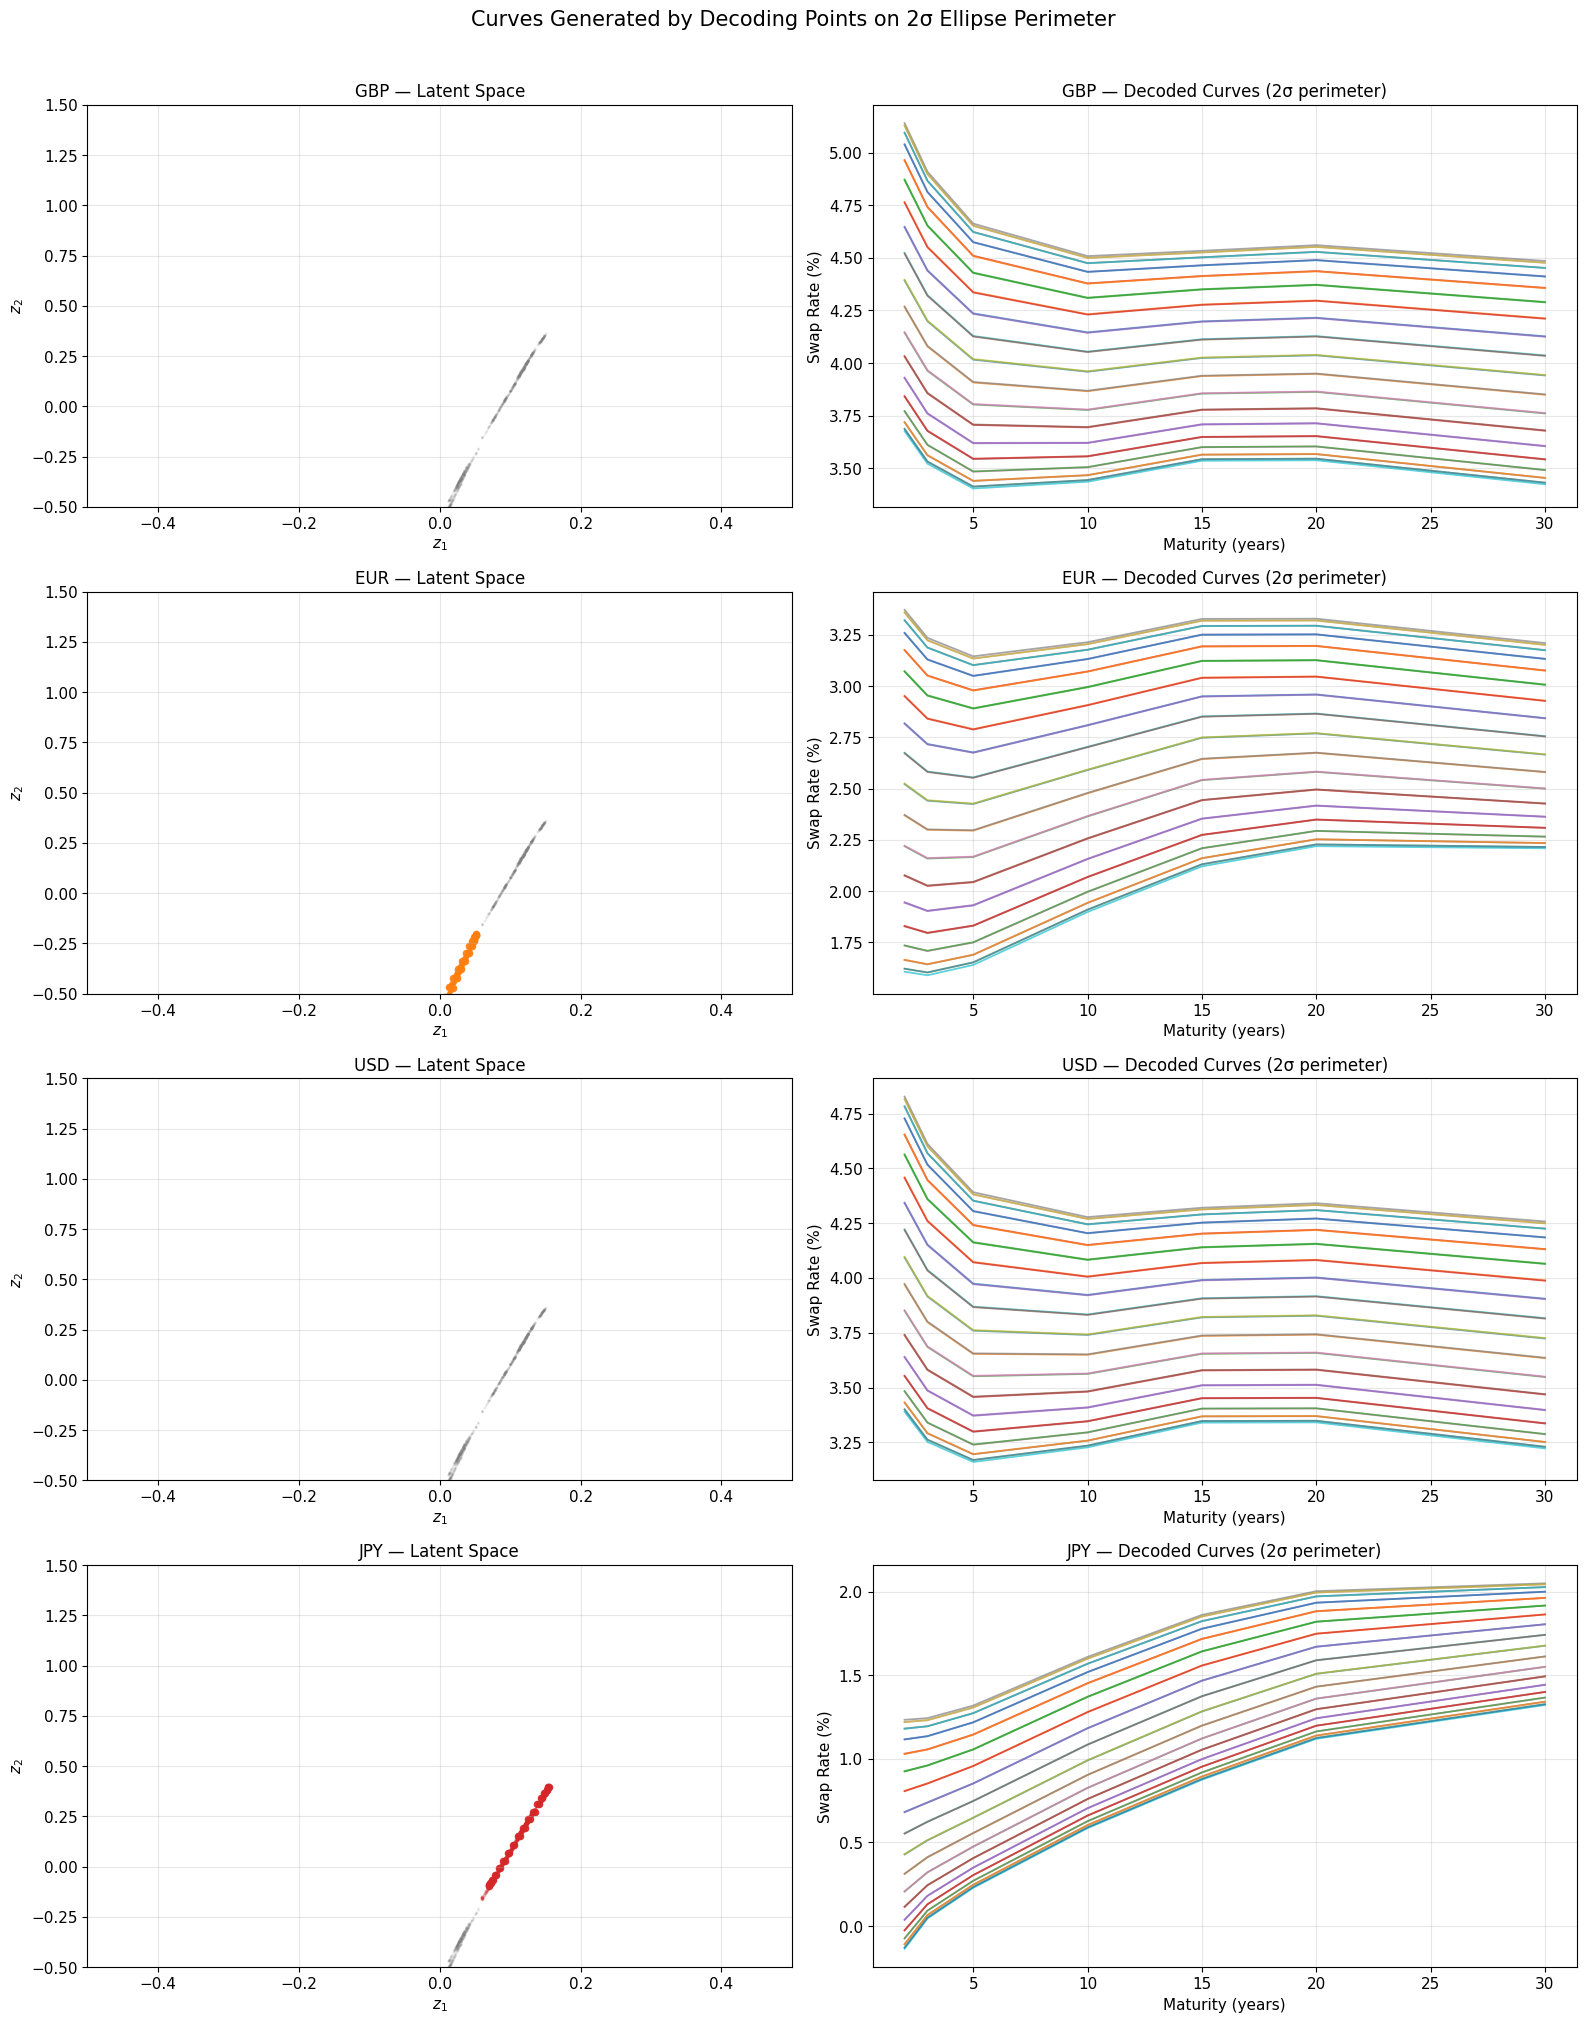

In [105]:
tenors = np.array(TARGET_TENORS, dtype=float)

fig, axes = plt.subplots(len(CURRENCIES), 2, figsize=(16, 5 * len(CURRENCIES)), squeeze=False)

offset = 0
z_global = multi_vae.get_latent(X_multi)  # for background scatter

for row, ccy in enumerate(CURRENCIES):
    n = len(swap_aligned[ccy])
    X_slice = X_multi[offset:offset+n]
    z_all = multi_vae.get_latent(X_slice)

    mean = z_all.mean(axis=0)
    cov = np.cov(z_all.T)
    evals, evecs = np.linalg.eigh(cov)

    thetas = np.linspace(0, 2 * np.pi, 36, endpoint=False)
    ellipse_pts = []
    for th in thetas:
        pt = mean + 2 * (evecs @ np.diag(np.sqrt(evals)) @ np.array([np.cos(th), np.sin(th)]))
        ellipse_pts.append(pt)
    ellipse_pts = np.array(ellipse_pts)

    # Left: latent
    axL = axes[row, 0]
    axL.scatter(z_global[:, 0], z_global[:, 1], s=1, alpha=0.08, color="gray")
    axL.scatter(z_all[:, 0], z_all[:, 1], s=3, alpha=0.25, color=colors[ccy])
    axL.scatter(ellipse_pts[:, 0], ellipse_pts[:, 1], s=20, alpha=0.9, color=colors[ccy])
    axL.set_title(f"{ccy} — Latent Space", fontsize=12)
    axL.set_xlabel("$z_1$")
    axL.set_ylabel("$z_2$")
    axL.set_xlim(-0.5, 0.5)
    axL.set_ylim(-0.5, 1.5)

    # Right: decoded curves (decimal -> plot in %)
    axR = axes[row, 1]
    z_tensor = torch.from_numpy(ellipse_pts.astype(np.float32)).to(device)
    with torch.no_grad():
        decoded_norm = multi_vae.decode(z_tensor).cpu().numpy()
    decoded_dec = denormalize_rates(decoded_norm)  # decimal
    for i in range(decoded_dec.shape[0]):
        axR.plot(tenors, 100.0 * decoded_dec[i], lw=1.3, alpha=0.7)  # percent display
    axR.set_title(f"{ccy} — Decoded Curves (2σ perimeter)", fontsize=12)
    axR.set_xlabel("Maturity (years)")
    axR.set_ylabel("Swap Rate (%)")

    offset += n

plt.suptitle("Curves Generated by Decoding Points on 2σ Ellipse Perimeter", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("figs/fig_10_ellipse_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 - Save trained models

In [106]:
vae_output = {
    "single_vae_models": {ccy: m.state_dict() for ccy, m in single_vae_models.items()},
    "multi_vae_state": multi_vae.state_dict(),
    "cvae_state": cvae.state_dict(),
    "rmse_results": rmse_results,
    "multi_vae_history": multi_vae_history,
    "cvae_history": cvae_history,
    "config": {
        "S_MIN": S_MIN,
        "S_MAX": S_MAX,
        "rates_units": "decimal",
        "bp_per_unit": BP_PER_UNIT,
        "latent_dim": 2,
        "input_dim": 7,
        "beta": 1e-7,
        "currencies": CURRENCIES,
        "target_tenors": TARGET_TENORS,
        "seed": SEED,
    },
}

with open("vae_results.pkl", "wb") as f:
    pickle.dump(vae_output, f)

torch.save(multi_vae.state_dict(), "multi_vae_weights.pt")
torch.save(cvae.state_dict(), "cvae_weights.pt")